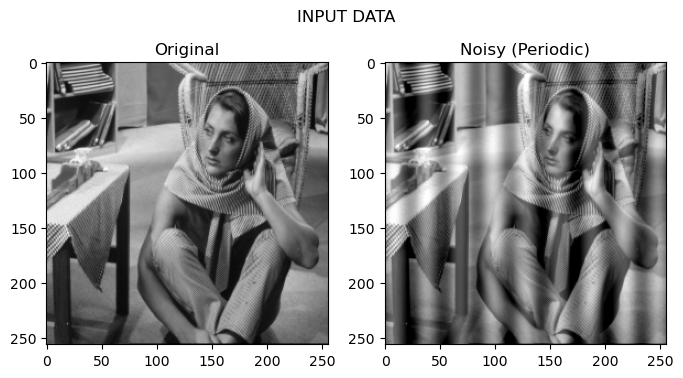

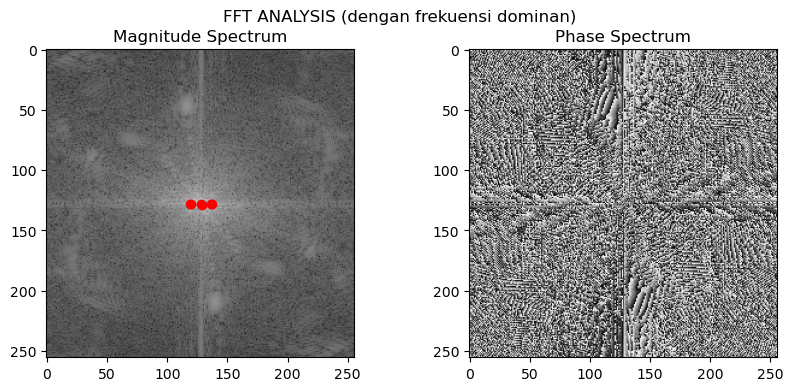

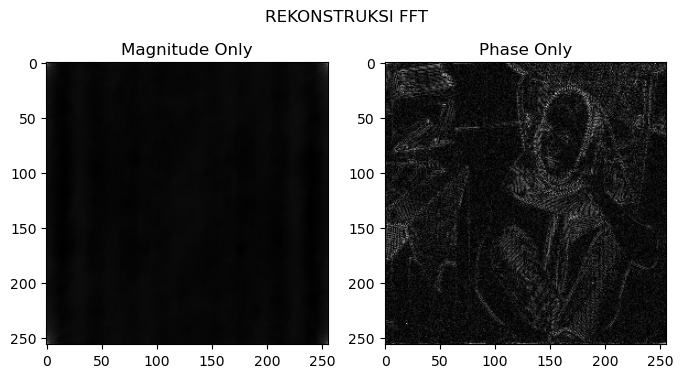

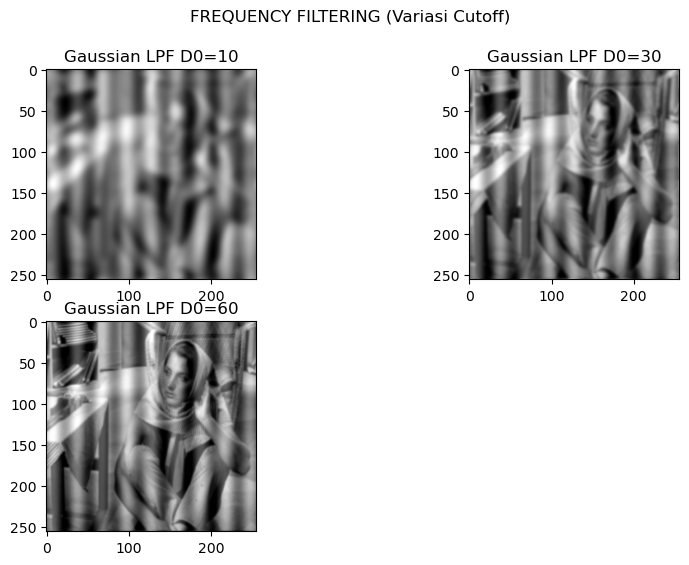

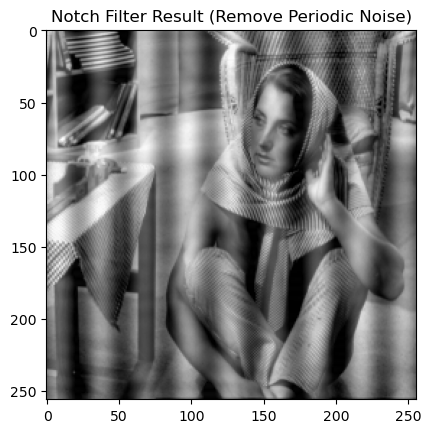

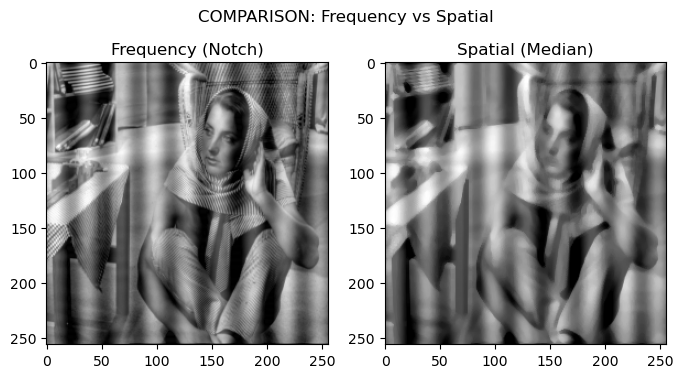

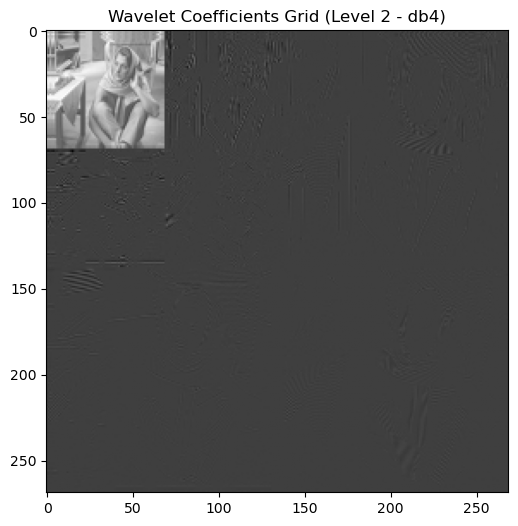

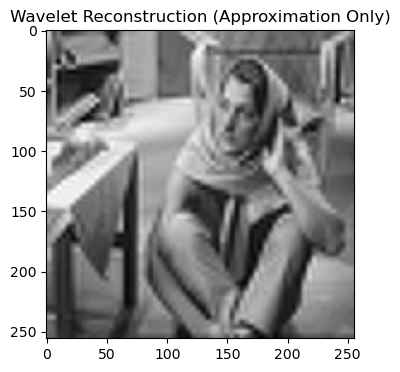


=== TABEL HASIL ===
              Metode       PSNR     Waktu (s)
0   Spatial (Median)  27.733711  7.152557e-07
1  Frequency (Notch)  17.211667  7.152557e-07
2            Wavelet  25.907389  4.768372e-07


In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pywt
import time
import pandas as pd

# =========================
# 1. INPUT (ORIGINAL vs NOISY)
# =========================
img = cv2.imread('barbara.jpg', 0)
img = cv2.resize(img, (256,256))

def add_periodic_noise(image, freq=30, amp=50):
    rows, cols = image.shape
    X, Y = np.meshgrid(np.arange(cols), np.arange(rows))
    noise = amp * np.sin(2 * np.pi * X / freq)
    return np.clip(image + noise, 0, 255).astype(np.uint8)

noisy = add_periodic_noise(img)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(img, cmap='gray'); plt.title("Original")
plt.subplot(1,2,2); plt.imshow(noisy, cmap='gray'); plt.title("Noisy (Periodic)")
plt.suptitle("INPUT DATA")
plt.show()

# =========================
# 2. PROSES - FFT
# =========================
F = np.fft.fft2(noisy)
F_shift = np.fft.fftshift(F)

mag = np.log(1 + np.abs(F_shift))
phase = np.angle(F_shift)

# DETEKSI PEAK
flat = mag.flatten()
idx = np.argsort(flat)[-6:]
coords = np.array(np.unravel_index(idx, mag.shape)).T

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(mag, cmap='gray')
plt.title("Magnitude Spectrum")

# tandai peak
for (y,x) in coords:
    plt.plot(x,y,'ro')

plt.subplot(1,2,2)
plt.imshow(phase, cmap='gray')
plt.title("Phase Spectrum")
plt.suptitle("FFT ANALYSIS (dengan frekuensi dominan)")
plt.show()

# =========================
# REKONSTRUKSI
# =========================
def reconstruct(F_shift, use_mag=True, use_phase=True):
    mag = np.abs(F_shift) if use_mag else np.ones_like(F_shift)
    ph = np.angle(F_shift) if use_phase else np.zeros_like(F_shift)
    img_back = np.fft.ifft2(np.fft.ifftshift(mag * np.exp(1j*ph)))
    return np.abs(img_back)

rec_mag = reconstruct(F_shift, True, False)
rec_phase = reconstruct(F_shift, False, True)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(rec_mag, cmap='gray'); plt.title("Magnitude Only")
plt.subplot(1,2,2); plt.imshow(rec_phase, cmap='gray'); plt.title("Phase Only")
plt.suptitle("REKONSTRUKSI FFT")
plt.show()

# =========================
# 3. OUTPUT - FILTERING
# =========================
def gaussian_filter(shape, D0):
    rows, cols = shape
    crow, ccol = rows//2, cols//2
    mask = np.zeros((rows, cols))
    for i in range(rows):
        for j in range(cols):
            D = np.sqrt((i-crow)**2 + (j-ccol)**2)
            mask[i,j] = np.exp(-(D**2)/(2*(D0**2)))
    return mask

def apply_filter(F_shift, mask):
    return np.abs(np.fft.ifft2(np.fft.ifftshift(F_shift * mask)))

cutoffs = [10, 30, 60]
results_freq = []

plt.figure(figsize=(10,6))
for i, D0 in enumerate(cutoffs):
    filtered = apply_filter(F_shift, gaussian_filter(img.shape, D0))
    results_freq.append(filtered)
    plt.subplot(2,2,i+1)
    plt.imshow(filtered, cmap='gray')
    plt.title(f"Gaussian LPF D0={D0}")

plt.suptitle("FREQUENCY FILTERING (Variasi Cutoff)")
plt.show()

# NOTCH FILTER
def notch_filter(shape, centers, r=5):
    rows, cols = shape
    mask = np.ones((rows, cols))
    for cx, cy in centers:
        for i in range(rows):
            for j in range(cols):
                if np.sqrt((i-cx)**2 + (j-cy)**2) < r:
                    mask[i,j] = 0
    return mask

centers = [(128+20,128),(128-20,128)]
notch = apply_filter(F_shift, notch_filter(img.shape, centers))

plt.figure()
plt.imshow(notch, cmap='gray')
plt.title("Notch Filter Result (Remove Periodic Noise)")
plt.show()

# =========================
# SPATIAL COMPARISON
# =========================
spatial = cv2.medianBlur(noisy, 5)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(notch, cmap='gray'); plt.title("Frequency (Notch)")
plt.subplot(1,2,2); plt.imshow(spatial, cmap='gray'); plt.title("Spatial (Median)")
plt.suptitle("COMPARISON: Frequency vs Spatial")
plt.show()

# =========================
# 4. PROSES - WAVELET
# =========================
coeffs = pywt.wavedec2(img, 'db4', level=2)

# VISUAL GRID
arr, slices = pywt.coeffs_to_array(coeffs)

plt.figure(figsize=(6,6))
plt.imshow(arr, cmap='gray')
plt.title("Wavelet Coefficients Grid (Level 2 - db4)")
plt.show()

# REKONSTRUKSI TANPA DETAIL
cA = coeffs[0]
new_coeffs = [cA] + [(np.zeros_like(cH), np.zeros_like(cV), np.zeros_like(cD)) for (cH,cV,cD) in coeffs[1:]]

wavelet_smooth = pywt.waverec2(new_coeffs, 'db4')

plt.figure(figsize=(6,4))
plt.imshow(wavelet_smooth, cmap='gray')
plt.title("Wavelet Reconstruction (Approximation Only)")
plt.show()

# =========================
# 5. DATA (PSNR + TIME)
# =========================
def psnr(a,b):
    mse = np.mean((a-b)**2)
    return 20*np.log10(255/np.sqrt(mse)) if mse !=0 else 100

data = []

def measure(name, func):
    start = time.time()
    result = func()
    end = time.time()
    return result, psnr(img, result), end-start

_, ps_spatial, t_spatial = measure("spatial", lambda: spatial)
_, ps_notch, t_notch = measure("notch", lambda: notch)
_, ps_wavelet, t_wavelet = measure("wavelet", lambda: wavelet_smooth)

data.append(["Spatial (Median)", ps_spatial, t_spatial])
data.append(["Frequency (Notch)", ps_notch, t_notch])
data.append(["Wavelet", ps_wavelet, t_wavelet])

df = pd.DataFrame(data, columns=["Metode","PSNR","Waktu (s)"])
print("\n=== TABEL HASIL ===")
print(df)